# Hierarchical ITS for staggered launches (event-study)

This notebook demonstrates `HierarchicalInterruptedTimeSeries`, a multi-unit ITS design where each unit (e.g. a product) has its **own** treatment time. Per-unit intercepts, **time trends**, covariate slopes and the launch "lift" are partially
pooled toward shared population-level hyperparameters, so sparse units borrow strength from well-observed ones and we recover a posterior over the population effect that can be used to forecast the impact of a *new* launch.

The model always includes **hierarchical (random) linear time trends** per unit, $\gamma_i \sim \mathcal{N}(\mu_\gamma, \sigma_\gamma)$, so that the baseline for each unit can drift over time rather than being a flat intercept. This is important for avoiding confounding between secular trends and the treatment effect.

Four effect parameterizations are available:

- `effect_type='instant'` &mdash; a single post-launch level shift per unit.
- `effect_type='saturation'` &mdash; a Hill (logistic-type) saturation curve: the effect ramps up smoothly after launch and asymptotes at a per-unit ceiling, rather than jumping instantly to its final size.
- `effect_type='event_study'` &mdash; dynamic effects across post-launch event-time bins.
- `effect_type='placebo'` &mdash; the event-study form extended with pre-launch leads as placebos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm

import causalpy as cp
from causalpy.pymc_models import HierarchicalLaunchITS

rng = np.random.default_rng(42)

## Shared simulation utilities

Each of the three model variants is designed to handle a different kind of
treatment effect, so in the sections below we simulate a **different** panel
for each one to show how faithfully it recovers the truth. The helpers below
build a panel of `N_PRODUCTS` products observed weekly over `T` weeks with
per-product intercepts, covariate slopes, shared seasonality, and a
user-supplied effect function `effect_fn(tau)` that returns the true causal
contribution for a given event time `tau = week - launch_week`.

In [2]:
N_PRODUCTS = 15
T = 200


def fourier_terms(t, period=52, K=2):
    cols = []
    for k in range(1, K + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)


def simulate_panel(effect_fn, seed, n_products=N_PRODUCTS, T=T):
    """Simulate a staggered-launch panel with a user-supplied effect function.

    ``effect_fn(tau, i)`` receives event time (weeks since launch) and the
    product index and returns the true causal contribution to sales.

    Each unit has its own linear time trend ``trend_i ~ N(0.01, 0.005)`` —
    small enough that the staggered design can separate it from the treatment
    effect, but large enough to exercise the model's time-trend component.
    """
    rng = np.random.default_rng(seed)
    alpha = rng.normal(50, 8, n_products)
    trend = rng.normal(0.01, 0.005, n_products)  # per-unit time trend
    gamma = rng.normal(0.15, 0.03, n_products)
    delta = rng.normal(-0.6, 0.1, n_products)
    launch_week = rng.integers(40, T - 80, n_products)

    week_idx = np.arange(T)
    season = fourier_terms(week_idx) @ np.array([6.0, -3.0, 2.0, -1.5])

    rows = []
    for i in range(n_products):
        emails = rng.normal(120, 25, T)
        price = rng.normal(20, 2, T)
        tau = week_idx - launch_week[i]
        effect = effect_fn(tau, i, rng)
        sales = (
            alpha[i]
            + trend[i] * week_idx  # linear time trend per unit
            + gamma[i] * emails
            + delta[i] * price
            + season
            + effect
            + rng.normal(0, 4, T)
        )
        rows.append(
            pd.DataFrame(
                {
                    "product": i,
                    "week_idx": week_idx,
                    "launch_week": launch_week[i],
                    "sales": sales,
                    "emails": emails,
                    "price": price,
                }
            )
        )
    return pd.concat(rows, ignore_index=True)

## Instant lift model

**DGP:** a flat post-launch step of size `lift_i ~ N(12, 4)`. Each product's effect is constant from the launch week onwards — the simplest causal story and the one the `instant` model is designed for.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_lift, sigma_lift, z_lift, sigma]
/Users/nathanielforde/mambaforge/envs/CausalPy/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 128 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_gamma, mu_lift, sigma, sigma_alpha, sigma_beta, sigma_gamma, sigma_lift, y

Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: instant
Units: 15
E[mu_lift] = 11.2   E[sigma_lift] = 2.61


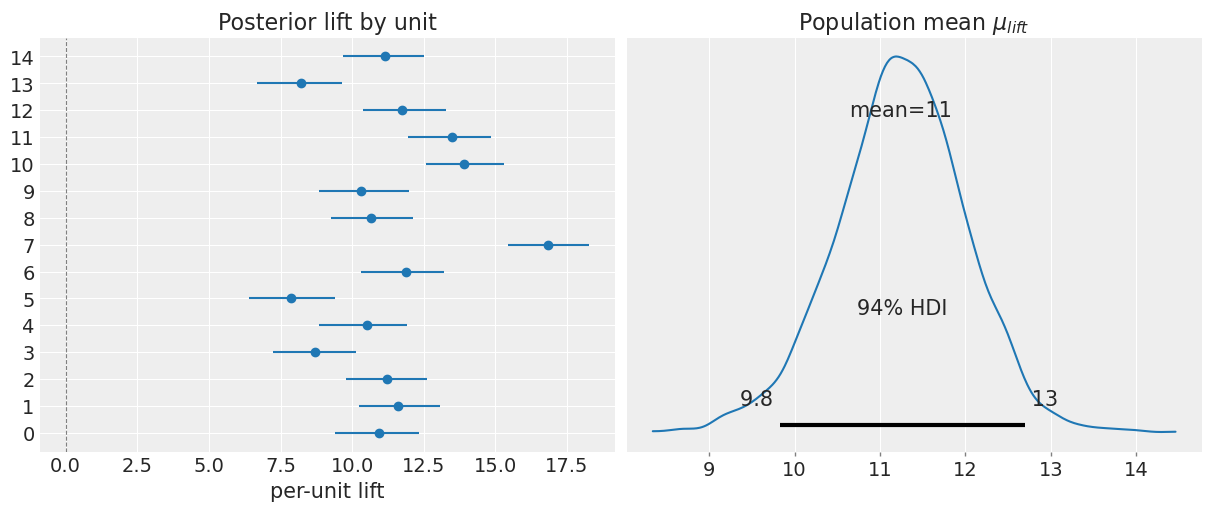

In [3]:
TRUE_MU_LIFT = 12.0
TRUE_SIGMA_LIFT = 4.0
_lift_rng = np.random.default_rng(7)
_lift_i = _lift_rng.normal(TRUE_MU_LIFT, TRUE_SIGMA_LIFT, N_PRODUCTS)


def instant_effect(tau, i, rng):
    return _lift_i[i] * (tau >= 0).astype(float)


df_instant = simulate_panel(instant_effect, seed=0)

result_instant = cp.HierarchicalInterruptedTimeSeries(
    data=df_instant,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="instant",
    seasonality={"period": 52, "K": 2},
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_instant.summary()
result_instant.plot();

### Inspecting the fitted model

Every fitted `HierarchicalInterruptedTimeSeries` exposes the full PyMC posterior via `result.idata` (an ArviZ `InferenceData` object). From here you can visualise the model graph, check convergence, extract effect summaries, and compute Bayesian R&sup2;.

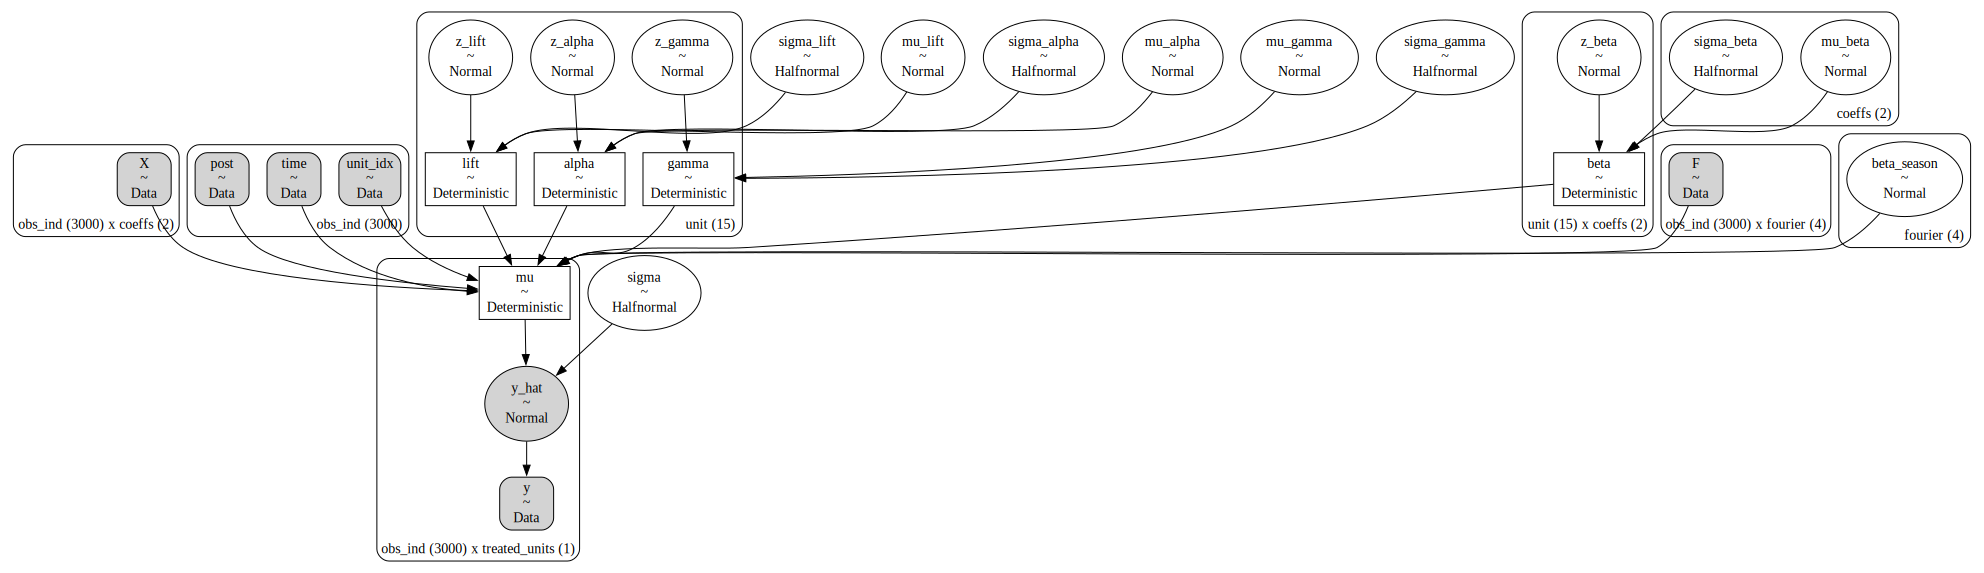

In [4]:
# The model DAG — shows all hierarchical parameters and their dependencies
pm.model_to_graphviz(result_instant.model)

In [5]:
import arviz as az

# Convergence diagnostics for key hyperparameters: R-hat near 1.0 and
# large ESS (effective sample size) indicate healthy sampling.
az.summary(
    result_instant.idata,
    var_names=["mu_lift", "sigma_lift", "mu_gamma", "sigma_gamma", "sigma"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_lift,11.240,0.766,9.831,12.698,0.028,0.017,776.0,1410.0,1.0
sigma_lift,2.612,0.584,1.623,3.670,0.017,0.014,1201.0,2026.0,1.0
mu_gamma,0.734,0.166,0.437,1.064,0.003,0.003,2949.0,2338.0,1.0
sigma_gamma,0.313,0.195,0.001,0.632,0.007,0.003,767.0,1001.0,1.0
sigma,3.974,0.052,3.882,4.073,0.001,0.001,6222.0,2970.0,1.0


In [6]:
# effect_summary() returns an EffectSummary with a .table (DataFrame) and
# .text (prose). The table reports posterior mean, HDI, and the probability
# that the effect is positive — a quick decision-making summary.
es = result_instant.effect_summary()
display(es.table)
print(es.text)

,mean,hdi_95_low,hdi_95_high,prob_positive
parameter,,,,
mu_lift,11.240289,9.649514,12.674919,1.0
sigma_lift,2.612079,1.709416,3.972569,1.0


Post-period: Hierarchical ITS (launch / event-study)
Effect type: instant
Units: 15


In [7]:
# Bayesian R² — how much variance in the outcome is explained by the model.
result_instant.score

unit_0_r2        0.892759
unit_0_r2_std    0.001286
dtype: float64

### Predictive distribution for a *new* launch

Because the model has a posterior over the population hyperparameters, we can sample the lift we would expect from a yet-unobserved product.

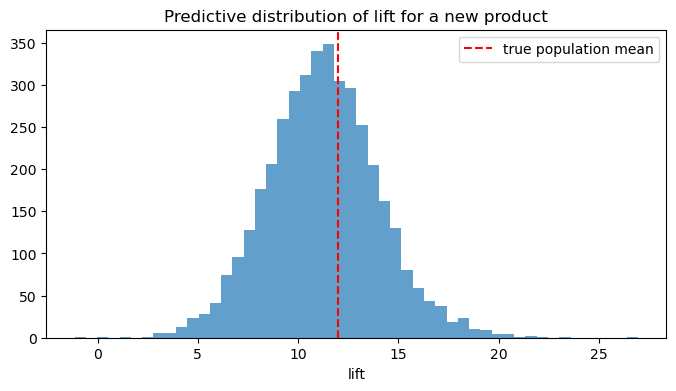

In [8]:
new_lift = result_instant.predictive_for_new_unit(size=4000, random_seed=0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(new_lift, bins=50, alpha=0.7)
ax.axvline(TRUE_MU_LIFT, color="red", ls="--", label="true population mean")
ax.set_title("Predictive distribution of lift for a new product")
ax.set_xlabel("lift")
ax.legend()
plt.show()

### Observed vs counterfactual (single unit)

The fitted experiment stores three key objects for causal reasoning:

- **`result.observed_pred`** &mdash; posterior predictive under the *actual*
  design (with treatment effect switched on).
- **`result.counterfactual_pred`** &mdash; posterior predictive under the
  counterfactual design (treatment effect zeroed out &mdash; what would have
  happened without launch).
- **`result.impact`** &mdash; `observed - counterfactual`, the unit-level
  posterior of the causal effect at every time point.

The `plot_unit()` method visualises all three for a single product.

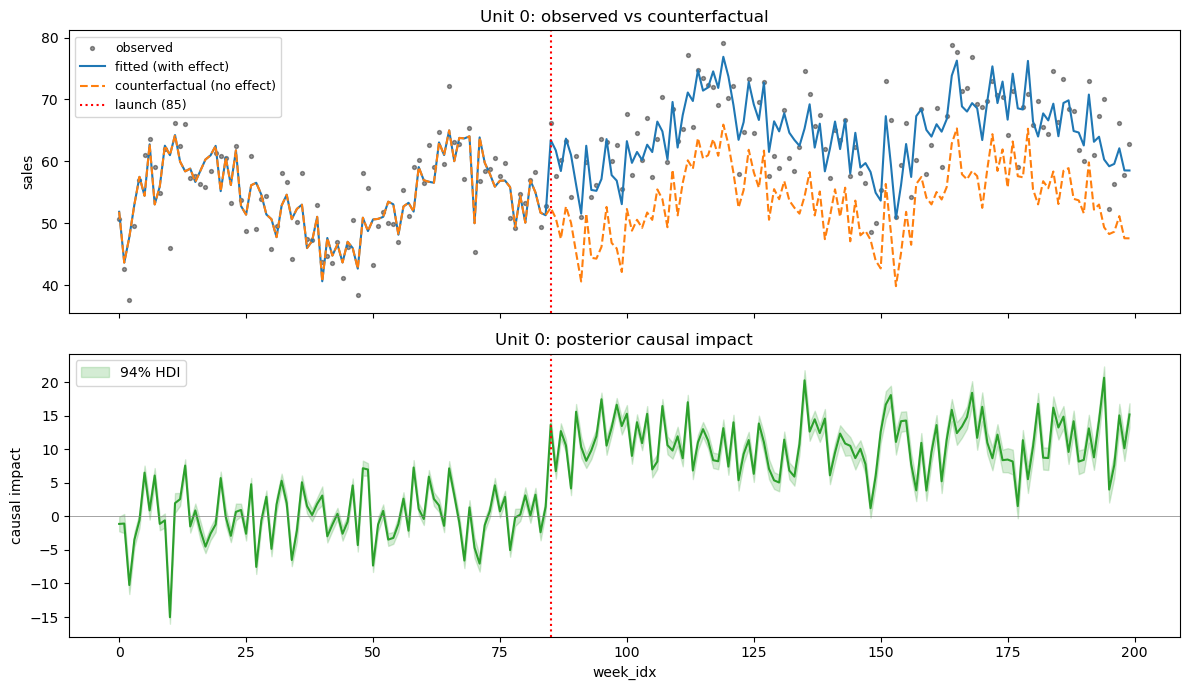

In [9]:
result_instant.plot_unit(unit_id=0)
plt.show()

## Saturation (Hill-curve) model

**DGP:** rather than an instant step, the true effect follows a **Hill (logistic-type) saturation curve** in event time — it ramps up smoothly after launch and asymptotes at a per-unit ceiling `L_i`, reaching half of that ceiling after `k_i` weeks:

$$
\text{effect}_i(\tau) = L_i \cdot \frac{\tau^s}{k_i^s + \tau^s}, \qquad \tau = \text{week} - \text{launch\_week} \ge 0
$$

This is the same functional form used for diminishing-returns / adstock saturation in media-mix models — here the "dose" is simply time-since-launch. It's a much closer description of how adoption, distribution build and awareness actually accumulate after a real launch than an instant jump. `effect_type='saturation'` fits `L_i` and `k_i` hierarchically per unit (log scale, non-centered); the Hill exponent `s` (curve sharpness) is a single shared population parameter.

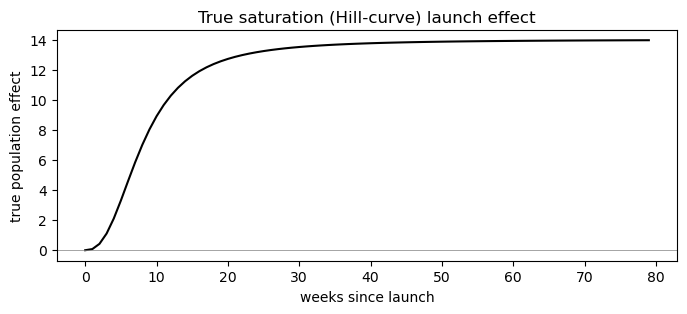

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_logL, sigma_logL, z_logL, mu_logk, sigma_logk, z_logk, s, sigma]
/Users/nathanielforde/mambaforge/envs/CausalPy/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 327 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_gamma, mu_logL, mu_logk, s, sigma, sigma_a

Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: saturation
Units: 15
E[L] (ceiling lift) = 14.7   E[k] (half-saturation time) = 8.43   E[s] (Hill exponent) = 2.55


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:621: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


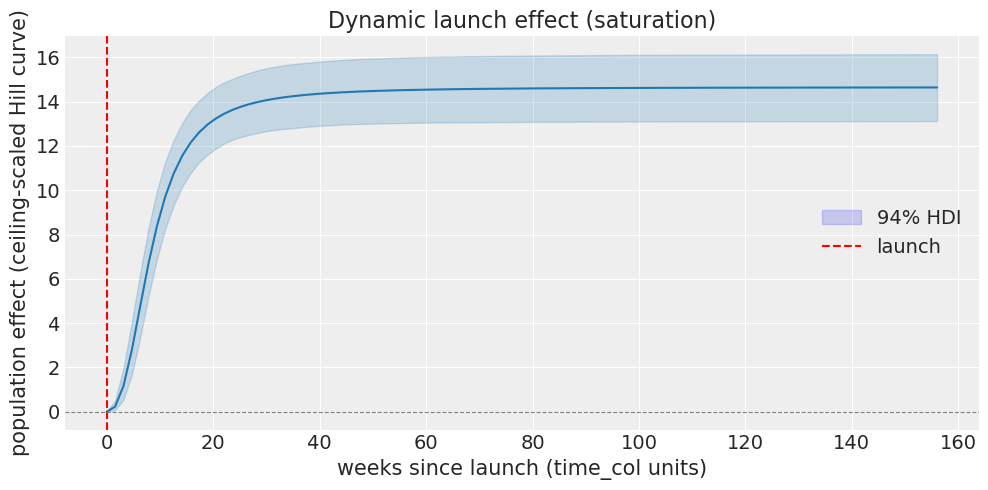

In [10]:
def hill(x, k, s):
    """Hill (logistic-type) saturation curve, x clipped to [0, inf)."""
    x = np.clip(np.asarray(x, dtype=float), 0, None)
    return x**s / (k**s + x**s)


TRUE_L_MEAN = 14.0  # ceiling lift, population mean
TRUE_L_SD_LOG = 0.15  # per-unit heterogeneity (log scale)
TRUE_K_MEAN = 8.0  # half-saturation time (weeks), population mean
TRUE_K_SD_LOG = 0.15
TRUE_S = 2.5  # Hill exponent (shared across units)

_sat_rng = np.random.default_rng(13)
_L_i = np.exp(_sat_rng.normal(np.log(TRUE_L_MEAN), TRUE_L_SD_LOG, N_PRODUCTS))
_k_i = np.exp(_sat_rng.normal(np.log(TRUE_K_MEAN), TRUE_K_SD_LOG, N_PRODUCTS))


def saturation_effect(tau, i, rng):
    return _L_i[i] * hill(tau, _k_i[i], TRUE_S)


df_saturation = simulate_panel(saturation_effect, seed=3)

# Show the true population saturation curve we expect to recover.
tau_grid = np.arange(0, 80)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_grid, TRUE_L_MEAN * hill(tau_grid, TRUE_K_MEAN, TRUE_S), color="black")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("weeks since launch")
ax.set_ylabel("true population effect")
ax.set_title("True saturation (Hill-curve) launch effect")
plt.show()

result_saturation = cp.HierarchicalInterruptedTimeSeries(
    data=df_saturation,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="saturation",
    seasonality={"period": 52, "K": 2},
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_saturation.summary()
result_saturation.plot();

### Convergence diagnostics and effect summary

`L` and `k` are fit hierarchically on the log scale (`mu_logL`/`sigma_logL`, `mu_logk`/`sigma_logk`); `s` is a single shared parameter. `effect_summary()` reports the population-level ceiling lift, half-saturation time and Hill exponent on their natural (exponentiated) scale.

In [11]:
# R-hat near 1.0 and large ESS indicate healthy sampling.
display(
    az.summary(
        result_saturation.idata,
        var_names=[
            "mu_logL",
            "sigma_logL",
            "mu_logk",
            "sigma_logk",
            "s",
            "mu_gamma",
            "sigma_gamma",
            "sigma",
        ],
    )
)

es = result_saturation.effect_summary()
display(es.table)
print(es.text)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_logL,2.683,0.056,2.573,2.780,0.002,0.001,1190.0,2143.0,1.0
sigma_logL,0.177,0.046,0.097,0.260,0.001,0.001,1535.0,1918.0,1.0
mu_logk,2.129,0.077,1.982,2.270,0.001,0.001,2859.0,3028.0,1.0
sigma_logk,0.233,0.074,0.100,0.365,0.002,0.001,1577.0,2572.0,1.0
s,2.553,0.269,2.061,3.078,0.004,0.004,5773.0,3226.0,1.0
mu_gamma,0.634,0.210,0.252,1.045,0.003,0.003,3850.0,3084.0,1.0
sigma_gamma,0.302,0.211,0.000,0.677,0.006,0.004,1026.0,1676.0,1.0
sigma,4.099,0.054,3.997,4.200,0.001,0.001,8317.0,2920.0,1.0


,mean,hdi_95_low,hdi_95_high,prob_positive
parameter,,,,
L (ceiling lift),14.650835,13.077124,16.244950,1.0
k (half-saturation time),8.433520,7.217934,9.774802,1.0
s (Hill exponent),2.553101,2.071411,3.148848,1.0


Post-period: Hierarchical ITS (launch / event-study)
Effect type: saturation
Units: 15


### Population predictive curve for a new unit

For `effect_type='saturation'`, `predictive_for_new_unit` returns a `(draws, 3)` array of `[L, k, s]` samples for a hypothetical new product. Turning each draw into a full Hill curve and overlaying the resulting predictive band on the true population curve shows how well the model recovers both *how big* (`L`) and *how fast* (`k`) the effect is.

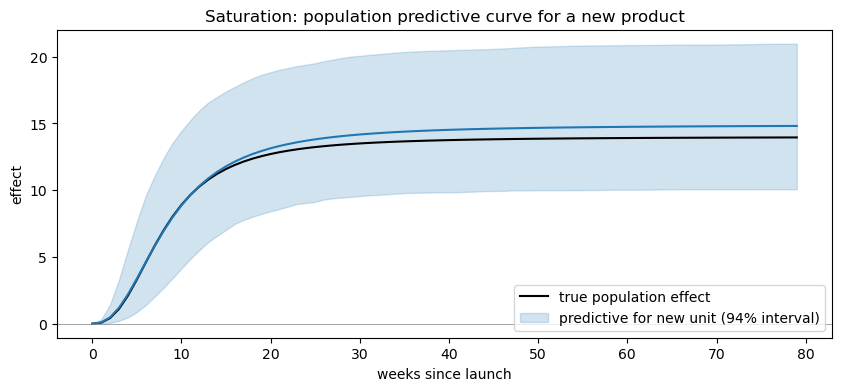

In [12]:
new_sat = result_saturation.predictive_for_new_unit(size=4000, random_seed=0)
# new_sat shape: (4000, 3) -> columns [L, k, s]
tau_grid = np.arange(0, 80)
L_draws, k_draws, s_draws = new_sat[:, 0], new_sat[:, 1], new_sat[:, 2]
curves = L_draws[:, None] * hill(tau_grid[None, :], k_draws[:, None], s_draws[:, None])
pred_mean = curves.mean(axis=0)
pred_lo = np.percentile(curves, 3, axis=0)
pred_hi = np.percentile(curves, 97, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    tau_grid,
    TRUE_L_MEAN * hill(tau_grid, TRUE_K_MEAN, TRUE_S),
    color="black",
    label="true population effect",
)
ax.fill_between(
    tau_grid,
    pred_lo,
    pred_hi,
    color="C0",
    alpha=0.2,
    label="predictive for new unit (94% interval)",
)
ax.plot(tau_grid, pred_mean, color="C0")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("weeks since launch")
ax.set_ylabel("effect")
ax.set_title("Saturation: population predictive curve for a new product")
ax.legend()
plt.show()

### Observed vs counterfactual (single unit)

Same three objects as the instant model (`observed_pred`, `counterfactual_pred`, `impact`) — but now the counterfactual gap traces out the shape of the Hill curve, ramping up after launch, rather than jumping instantly to a constant lift.

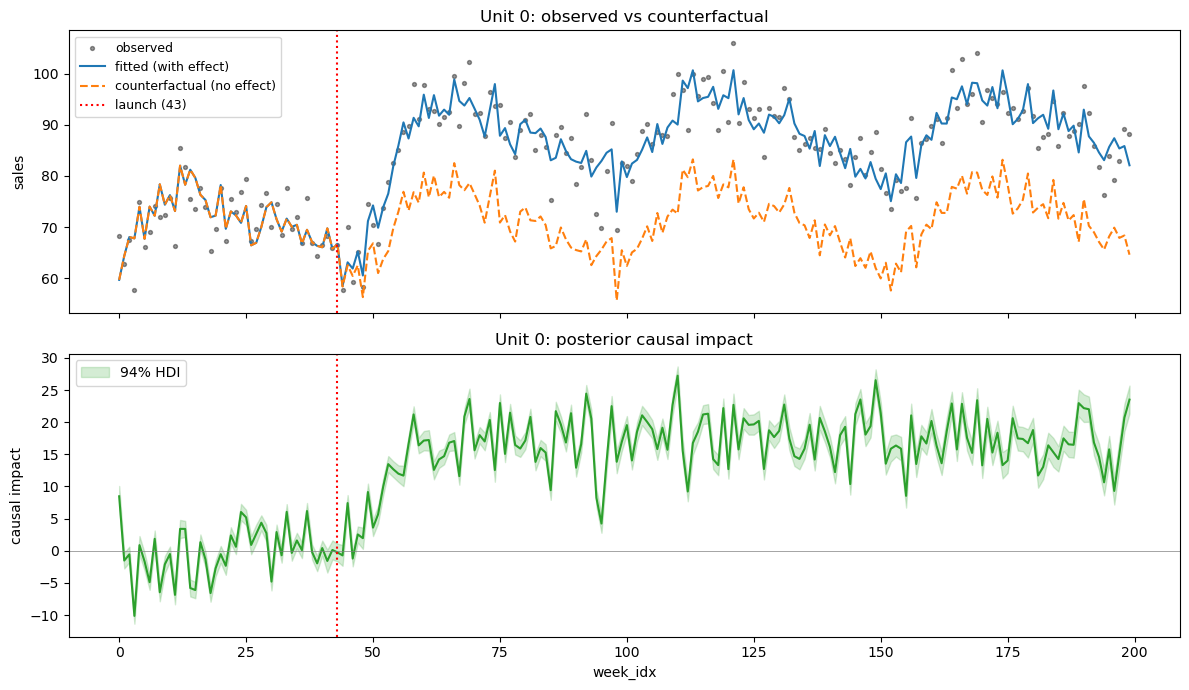

In [13]:
result_saturation.plot_unit(unit_id=0)
plt.show()

## Event-study (dynamic) model

**DGP:** a realistic launch curve — awareness ramps up over the first few weeks, peaks around week 8, then decays toward a lower long-run level as novelty wears off. A single "instant" lift would average this over time and miss the story entirely; the event-study variant estimates a separate population effect per post-launch bin and should trace out the true curve.

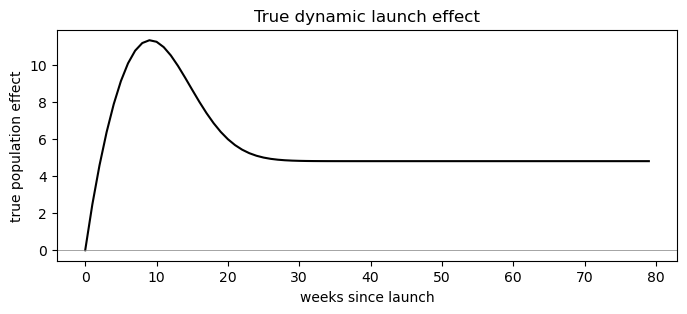

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
/Users/nathanielforde/mambaforge/envs/CausalPy/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 221 seconds.
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, mu_gamma, sigma, sigma_alpha, sigma_beta, sigma_delta, sigma_gamma, y_hat, z_alpha, z_beta, z_delta, z_gamma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: event_study
Units: 15
  [0,4)               mu_delta = +4.02
  [4,8)               mu_delta = +8.87
  [8,12)              mu_delta = +11.7
  [12,16)             mu_delta = +9.82
  [16,20)             mu_delta = +7.06
  [20,26)             mu_delta = +5.48
  [26,39)             mu_delta = +4.82
  [39,52)             mu_delta = +5.05
  [52,78)             mu_delta = +5.01
  [78,10000)          mu_delta = +5.1


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:668: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


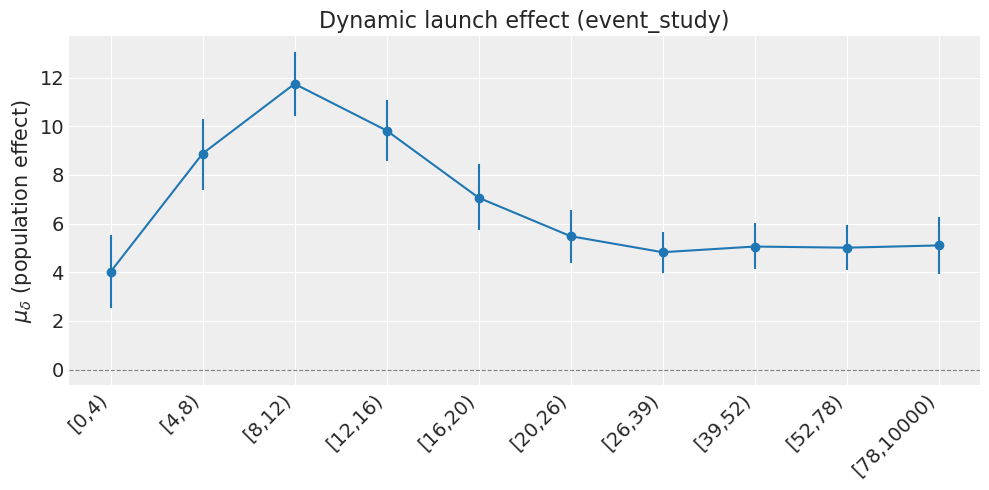

In [14]:
TRUE_MU_AMP = 12.0
TRUE_SIGMA_AMP = 3.0
_amp_rng = np.random.default_rng(11)
_amp_i = _amp_rng.normal(TRUE_MU_AMP, TRUE_SIGMA_AMP, N_PRODUCTS)


def launch_shape(tau):
    """Ramp-up, peak around week 8, decay toward ~40% long-run level."""
    tau = np.asarray(tau, dtype=float)
    return np.where(
        tau < 0,
        0.0,
        (1 - np.exp(-tau / 3.0)) * (0.4 + 0.6 * np.exp(-((tau - 8.0) ** 2) / 80.0)),
    )


def dynamic_effect(tau, i, rng):
    return _amp_i[i] * launch_shape(tau)


df_event = simulate_panel(dynamic_effect, seed=1)

# Show the true population event-time curve we expect to recover.
tau_grid = np.arange(0, 80)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tau_grid, TRUE_MU_AMP * launch_shape(tau_grid), color="black")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("weeks since launch")
ax.set_ylabel("true population effect")
ax.set_title("True dynamic launch effect")
plt.show()

result_event = cp.HierarchicalInterruptedTimeSeries(
    data=df_event,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="event_study",
    bin_edges=[0, 4, 8, 12, 16, 20, 26, 39, 52, 78, 10000],
    seasonality={"period": 52, "K": 2},
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_event.summary()
result_event.plot();

### Population predictive for a new unit

For the event-study variant, `predictive_for_new_unit` returns a `(draws, n_bins)` array &mdash; one draw from $\mathcal{N}(\mu_\delta, \sigma_\delta)$ per bin per posterior sample. We can overlay the posterior mean and HDI on the true population curve to see how well the model recovers the dynamic launch shape.

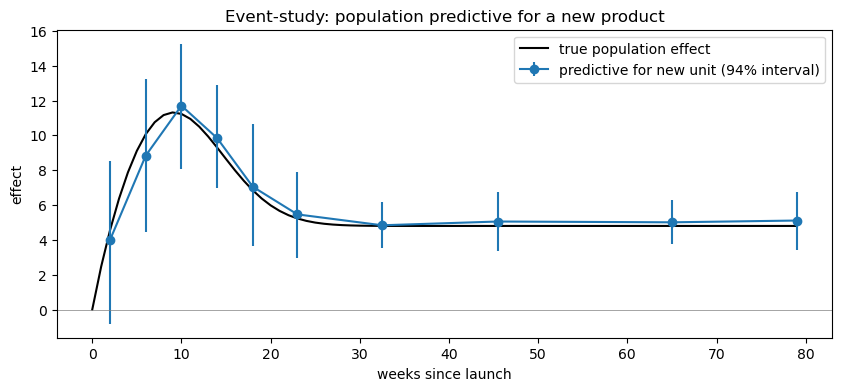

In [15]:
new_delta = result_event.predictive_for_new_unit(size=4000, random_seed=0)
# new_delta shape: (4000, n_bins)
bin_edges = [0, 4, 8, 12, 16, 20, 26, 39, 52, 78, 10000]
bin_mids = [
    0.5 * (bin_edges[k] + min(bin_edges[k + 1], 80)) for k in range(len(bin_edges) - 1)
]

fig, ax = plt.subplots(figsize=(10, 4))
# True curve
tau_grid = np.arange(0, 80)
ax.plot(
    tau_grid,
    TRUE_MU_AMP * launch_shape(tau_grid),
    color="black",
    label="true population effect",
)
# Posterior predictive for new unit
pred_mean = new_delta.mean(axis=0)
pred_lo = np.percentile(new_delta, 3, axis=0)
pred_hi = np.percentile(new_delta, 97, axis=0)
ax.errorbar(
    bin_mids,
    pred_mean,
    yerr=np.vstack([pred_mean - pred_lo, pred_hi - pred_mean]),
    fmt="o-",
    color="C0",
    label="predictive for new unit (94% interval)",
)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("weeks since launch")
ax.set_ylabel("effect")
ax.set_title("Event-study: population predictive for a new product")
ax.legend()
plt.show()

## Placebo (lead/lag) model

**DGP:** we generate *two* panels from the **same random seed** (so the noise, covariates and launch weeks are identical) but with different treatment effects:

1. **With anticipation** — the ramp/peak/decay post-launch curve plus a
   deliberate pre-launch linear build-up over the 8 weeks before launch
   (e.g. a pre-order period). The placebo bins in `[-8, -4)` and `[-4, 0)`
   should absorb this and the automatic check should **fail**.
2. **Without anticipation** — the same post-launch dynamics but strictly zero
   before launch. The placebo bins should be indistinguishable from zero and
   the check should **pass**.

Because the only difference between the two panels is the anticipation component, the contrast isolates exactly what the placebo test is designed to detect.

=== Panel WITH anticipation (placebo check should FAIL) ===


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 573 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, mu_gamma, sigma, sigma_alpha, sigma_beta, sigma_delta, sigma_gamma, y_hat, z_alpha, z_beta, z_delta, z_gamma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: placebo
Units: 15
  pre[-26,-20)        mu_delta = -0.364
  pre[-20,-16)        mu_delta = +0.684
  pre[-16,-12)        mu_delta = -0.296
  pre[-12,-8)         mu_delta = +0.515
  pre[-8,-4)          mu_delta = +0.365
  pre[-4,0)           mu_delta = +3.32
  post[0,4)           mu_delta = +2.96
  post[4,8)           mu_delta = +9.27
  post[8,12)          mu_delta = +11.3
  post[12,16)         mu_delta = +10.2
  post[16,20)         mu_delta = +7.4
  post[20,26)         mu_delta = +5.73
  post[26,39)         mu_delta = +4.85
  post[39,52)         mu_delta = +4.31
  post[52,78)         mu_delta = +4.34
  post[78,10000)      mu_delta = +3.99
Placebo check: FAIL (5/6 pre-launch bins contain 0 within the 94% HDI)


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:668: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


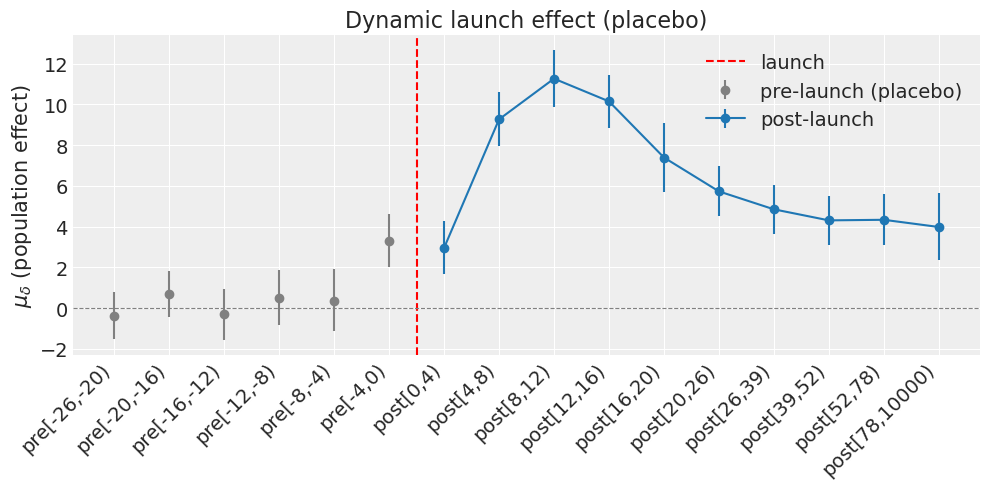

In [16]:
def anticipation_effect(tau, i, rng):
    """Dynamic post-launch effect + pre-launch build-up over 8 weeks."""
    post = _amp_i[i] * launch_shape(tau)
    tau_arr = np.asarray(tau, dtype=float)
    lead = np.where(
        (tau_arr >= -8) & (tau_arr < 0),
        _amp_i[i] * 0.4 * (tau_arr + 8) / 8.0,  # linear ramp up to ~40% of amp
        0.0,
    )
    return post + lead


def clean_dynamic_effect(tau, i, rng):
    """Same post-launch dynamics, but strictly zero before launch."""
    return _amp_i[i] * launch_shape(tau)


# Same seed → identical noise; only difference is the anticipation component
df_placebo_bad = simulate_panel(anticipation_effect, seed=2)
df_placebo_clean = simulate_panel(clean_dynamic_effect, seed=2)


def make_placebo_model():
    return HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.97,
            "random_seed": 42,
            "progressbar": False,
        }
    )


placebo_kwargs = dict(
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="placebo",
    bin_edges=[0, 4, 8, 12, 16, 20, 26, 39, 52, 78, 10000],
    placebo_edges=[-26, -20, -16, -12, -8, -4, 0],
    seasonality={"period": 52, "K": 2},
)

print("=== Panel WITH anticipation (placebo check should FAIL) ===")
result_placebo_bad = cp.HierarchicalInterruptedTimeSeries(
    data=df_placebo_bad, model=make_placebo_model(), **placebo_kwargs
)
result_placebo_bad.summary()
result_placebo_bad.plot();

=== Same noise, NO anticipation (placebo check should PASS) ===


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_delta, sigma_delta, z_delta, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 600 seconds.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_delta, mu_gamma, sigma, sigma_alpha, sigma_beta, sigma_delta, sigma_gamma, y_hat, z_alpha, z_beta, z_delta, z_gamma]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: placebo
Units: 15
  pre[-26,-20)        mu_delta = -0.377
  pre[-20,-16)        mu_delta = +0.673
  pre[-16,-12)        mu_delta = -0.311
  pre[-12,-8)         mu_delta = +0.494
  pre[-8,-4)          mu_delta = -0.56
  pre[-4,0)           mu_delta = -0.0915
  post[0,4)           mu_delta = +2.97
  post[4,8)           mu_delta = +9.29
  post[8,12)          mu_delta = +11.2
  post[12,16)         mu_delta = +10.2
  post[16,20)         mu_delta = +7.41
  post[20,26)         mu_delta = +5.76
  post[26,39)         mu_delta = +4.86
  post[39,52)         mu_delta = +4.33
  post[52,78)         mu_delta = +4.36
  post[78,10000)      mu_delta = +4.02
Placebo check: PASS (6/6 pre-launch bins contain 0 within the 94% HDI)


/Users/nathanielforde/Documents/Github/CausalPy/causalpy/experiments/hierarchical_interrupted_time_series.py:668: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


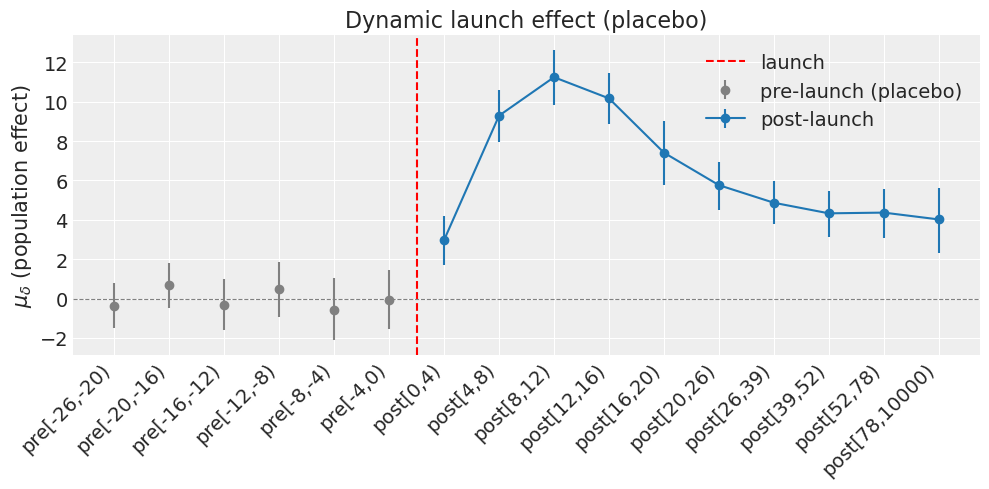

In [17]:
print("=== Same noise, NO anticipation (placebo check should PASS) ===")
result_placebo_ok = cp.HierarchicalInterruptedTimeSeries(
    data=df_placebo_clean, model=make_placebo_model(), **placebo_kwargs
)
result_placebo_ok.summary()
result_placebo_ok.plot();

### Model diagnostics

The underlying `HierarchicalLaunchITS` is a standard PyMC model, so we can use `pm.model_to_graphviz` to visualise the DAG, ArviZ trace plots to check convergence, and `az.summary` for R-hat / ESS diagnostics. These are essential sanity checks before trusting the causal estimates.

**Model graph** &mdash; the plate diagram shows the hierarchical structure: population hyperparameters at the top, per-unit parameters inside the "unit" plate, and the likelihood at the bottom.

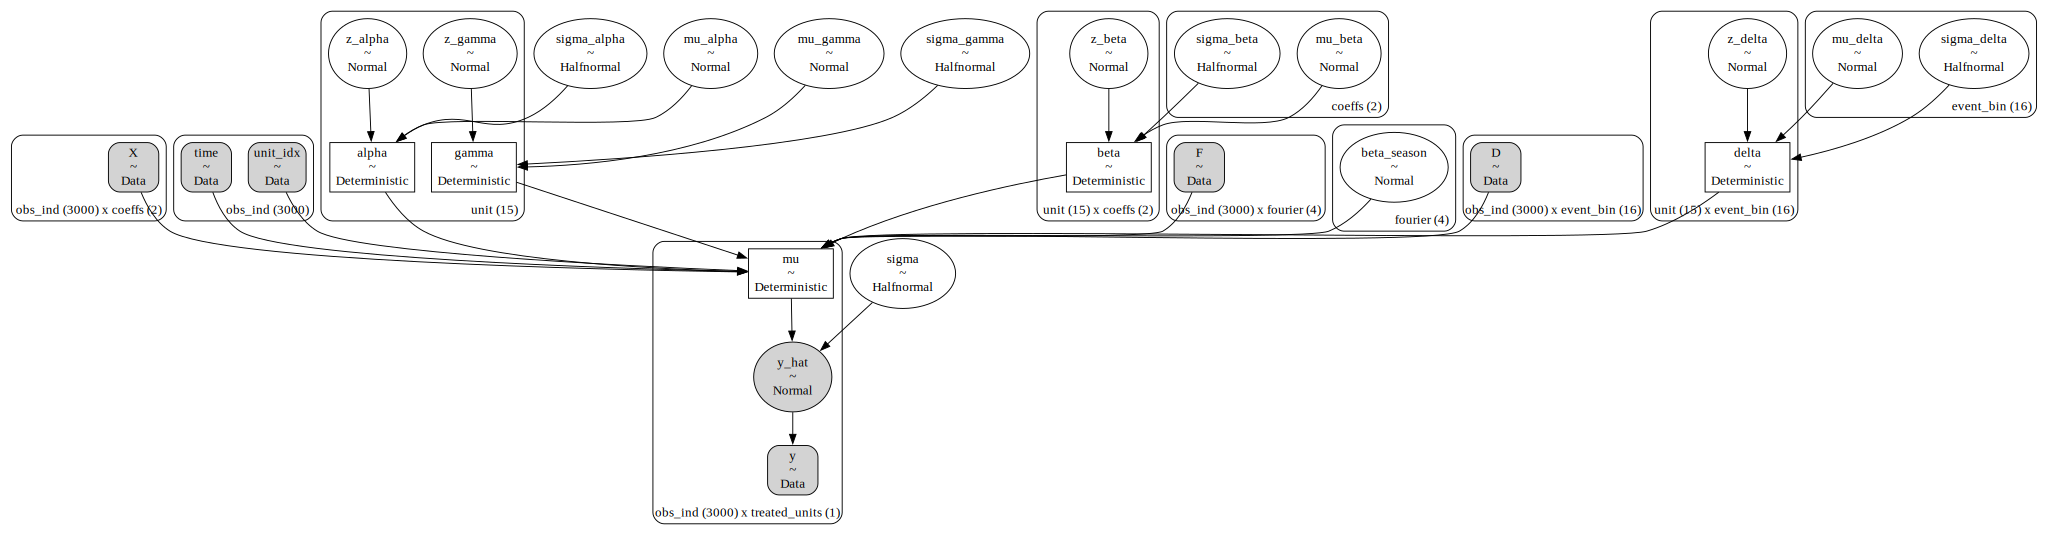

In [18]:
pm.model_to_graphviz(result_placebo_ok.model)

**Trace plots** &mdash; each row shows a population-level hyperparameter.
Look for: chains that overlap and appear stationary (good mixing), no
sustained trends, and no divergences flagged in the sampling output. The
right-hand marginal posteriors should be smooth and unimodal.

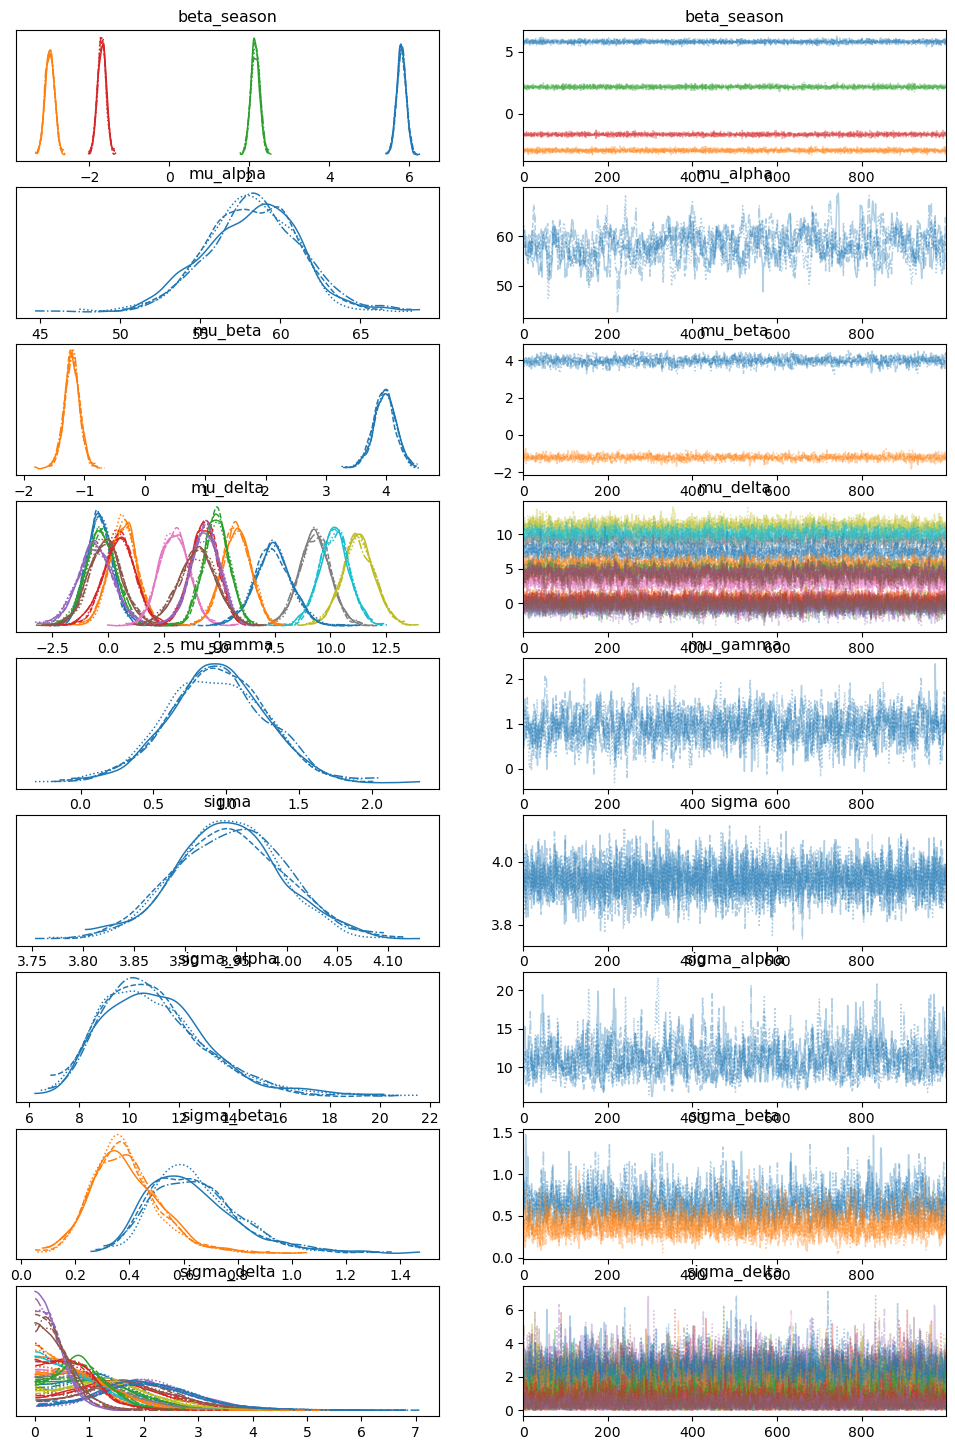

In [19]:
import arviz as az

az.plot_trace(
    result_placebo_ok.idata,
    var_names=[
        "beta_season",
        "mu_alpha",
        "mu_beta",
        "mu_delta",
        "mu_gamma",
        "sigma",
        "sigma_alpha",
        "sigma_beta",
        "sigma_delta",
    ],
)
plt.show()

**Per-unit effect profiles** &mdash; each panel below shows one product's posterior `delta` coefficients across the 16 event-time bins (6 pre-launch placebos + 10 post-launch).

In [20]:
fig, axs = plt.subplots(5, 3, figsize=(12, 7), sharex=True, sharey=True)
axs = axs.flatten()
summary_delta = az.summary(result_placebo_ok.idata, var_names=["delta"], hdi_prob=0.94)
summary_delta["index_col"] = summary_delta.index

summary_delta["index_col"] = summary_delta["index_col"].str.split("delta\[").str[1]
summary_delta["index_col"] = (
    summary_delta["index_col"].str.split(",").str[0].astype(int)
)
for i, ax in enumerate(axs):
    row = summary_delta[summary_delta["index_col"] == i]
    ax.plot(range(16), row["mean"], marker="o", ls="-", color="blue")
    ax.fill_between(range(16), row["hdi_3%"], row["hdi_97%"], color="blue", alpha=0.2)
    ax.set_title(f"Lifts across Launch {i}")
plt.tight_layout()

## AR(1) residuals (optional)

Time series residuals are rarely i.i.d.  When autocorrelation is present, the default Normal noise can produce overconfident uncertainty intervals. Passing `ar_residuals=True` adds a **hierarchical AR(1)** process to the residuals, implemented via `pytensor.scan`:

$$
e_{i,t} = \rho_i \, e_{i,t-1} + \varepsilon_{i,t}, \qquad
\rho_i \sim \tanh\!\bigl(\mathcal{N}(\mu_\rho, \sigma_\rho)\bigr)
$$

The `tanh` link ensures stationarity ($|\rho_i| < 1$). This requires a **balanced panel** (all units observed at the same time steps).

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z_alpha, mu_gamma, sigma_gamma, z_gamma, mu_beta, sigma_beta, z_beta, beta_season, mu_lift, sigma_lift, z_lift, mu_rho, sigma_rho, z_rho, z_ar, sigma_ar, sigma]
Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 377 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta_season, mu_alpha, mu_beta, mu_gamma, mu_lift, mu_rho, sigma, sigma_alpha, sigma_ar, sigma_beta, sigma_gamma, sigma_lift, sigma_rho, y_hat, z_alpha, z_ar, z_beta, z_gamma, z_lift, z_rho]
Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


Hierarchical ITS (launch / event-study)
Formula: sales ~ 0 + emails + price
Effect type: instant
Units: 15
E[mu_lift] = 11.3   E[sigma_lift] = 2.61


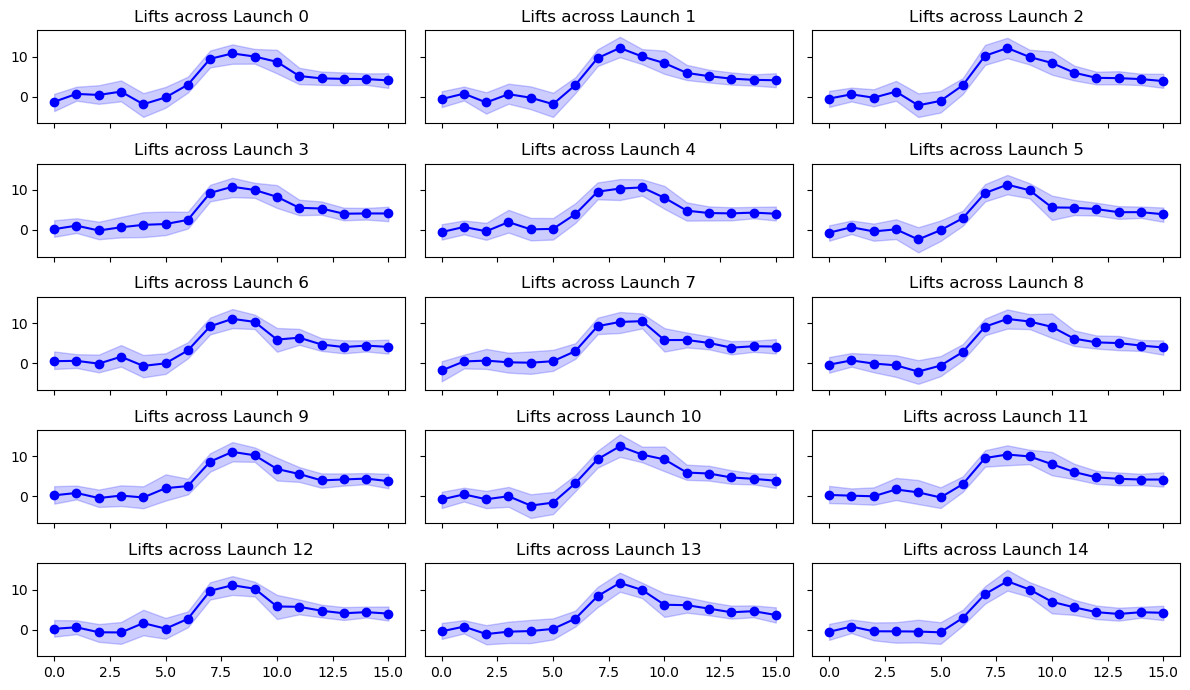

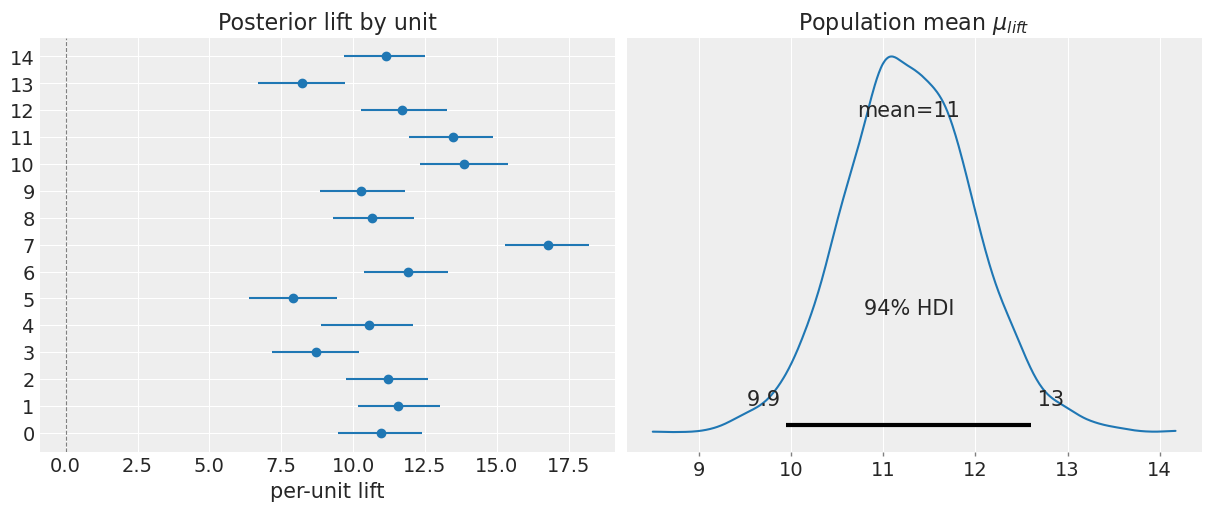

In [21]:
result_ar = cp.HierarchicalInterruptedTimeSeries(
    data=df_instant,
    formula="sales ~ 0 + emails + price",
    unit_col="product",
    time_col="week_idx",
    treatment_time_col="launch_week",
    effect_type="instant",
    seasonality={"period": 52, "K": 2},
    ar_residuals=True,
    model=HierarchicalLaunchITS(
        sample_kwargs={
            "draws": 1000,
            "tune": 1500,
            "chains": 4,
            "target_accept": 0.95,
            "random_seed": 42,
            "progressbar": False,
        }
    ),
)
result_ar.summary()
result_ar.plot();

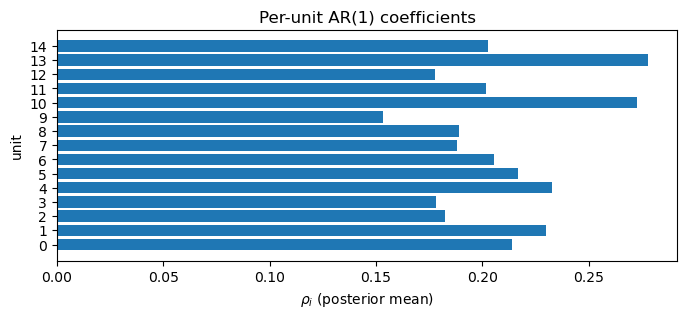

In [22]:
post_ar = result_ar.model.idata.posterior
rho_mean = post_ar["rho"].mean(("chain", "draw")).values
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(range(len(rho_mean)), rho_mean)
ax.set_yticks(range(len(rho_mean)))
ax.set_xlabel(r"$\rho_i$ (posterior mean)")
ax.set_ylabel("unit")
ax.set_title("Per-unit AR(1) coefficients")
ax.axvline(0, color="grey", lw=0.5)
plt.show()

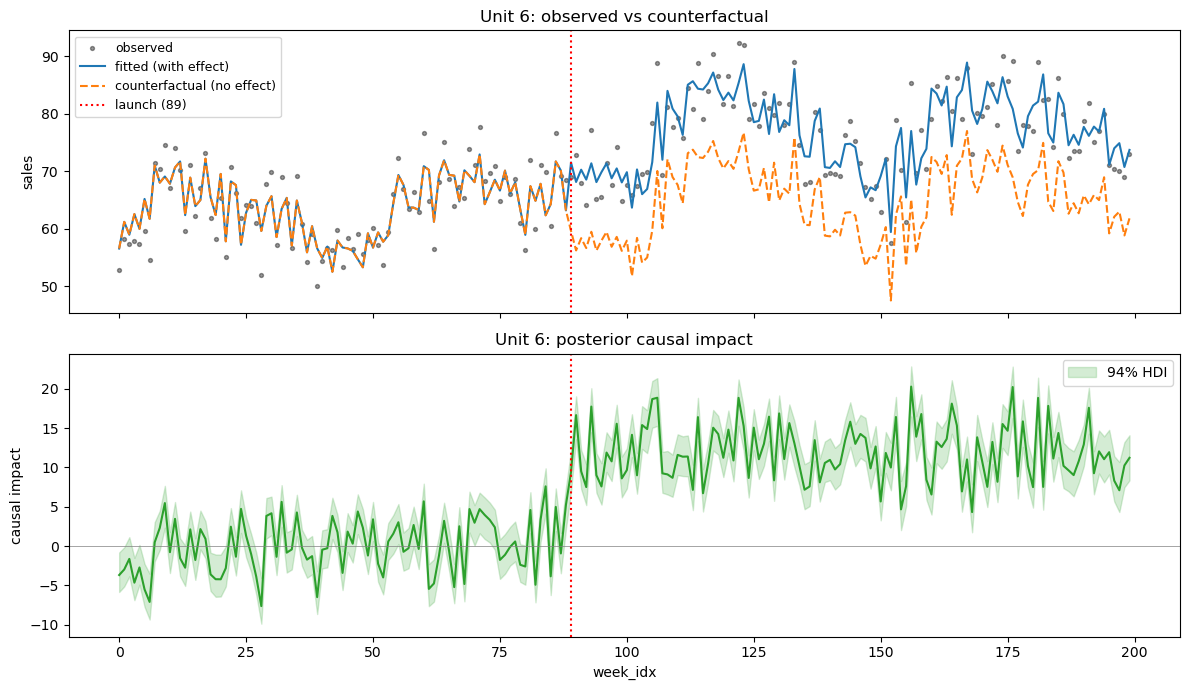

In [23]:
result_ar.plot_unit(unit_id=6)
plt.show()

## Notes on the implementation

- All hierarchical parameters use a non-centered parametrization for sampler health.
- **Hierarchical linear time trends** $\gamma_i \sim \mathcal{N}(\mu_\gamma, \sigma_\gamma)$
  are always included, allowing each unit's baseline to drift linearly over time.
  The time index is standardized internally for numerical stability.
- **Saturation (`effect_type='saturation'`)** replaces the instant level shift with a
  Hill curve, $\text{effect}_i(\tau) = L_i \, \tau^s / (k_i^s + \tau^s)$. The ceiling
  lift $L_i$ and half-saturation time $k_i$ are hierarchical per unit (log scale,
  non-centered); the Hill exponent $s$ is a single shared population parameter.
  `mu_logk`/`sigma_logk`/`s` use fixed, generic priors (not data-adaptive to
  `time_col`'s scale) — override them via `priors=` if your time index isn't in
  "a handful of periods to ramp up" units, e.g. daily rather than weekly data.
- **Optional AR(1) residuals** (`ar_residuals=True`) add per-unit autocorrelated
  noise via `pytensor.scan`. The AR coefficient is constrained to $(-1, 1)$ via
  a `tanh` link and partially pooled across units. Requires a balanced panel.
- Priors on population-level scale parameters are derived from the data via
  `priors_from_data` so the model is approximately scale-invariant.
- Covariates from the patsy formula are standardized internally; the
  hierarchical $\alpha$ takes the place of an intercept (you should not
  include one in `formula`). `print_coefficients()` also reports covariate
  coefficients back on their original (unstandardized) scale.
- Any prior can be overridden via the `priors=` argument to
  `HierarchicalLaunchITS` using the `pymc_extras.prior.Prior` system.